# Ejercicio 4 - Dataset de Kaggle, modelo y ejemplos externos


## Enunciado
De la librería de Kaggle para Python, descargar un dataset, estudiar sus características (**features**) y su rótulo. Generar un modelo y tomar ejemplos de internet para analizar los resultados.

## Dataset elegido
Se utiliza **Iris Species** de Kaggle/UCI. Contiene cuatro características numéricas de la flor:

- longitud del sépalo
- ancho del sépalo
- longitud del pétalo
- ancho del pétalo

El rótulo es la especie: *Iris-setosa*, *Iris-versicolor* o *Iris-virginica*.

El modelo utilizado es una red neuronal multicapa (MLP) de dos capas ocultas.

In [ ]:
# Si es necesario, instalar:
# !pip install kagglehub tensorflow scikit-learn pandas matplotlib

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Descargar el dataset directamente desde Kaggle
path = kagglehub.dataset_download("uciml/iris")
print("Ruta descargada:", path)

# Buscar el CSV principal
csv_files = glob.glob(os.path.join(path, "**", "Iris.csv"), recursive=True)

if not csv_files:
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

print("Archivos CSV encontrados:", csv_files)

df = pd.read_csv(csv_files[0])
display(df.head())
print("Dimensiones:", df.shape)

Using Colab cache for faster access to the 'iris' dataset.
Ruta descargada: /kaggle/input/iris
Archivos CSV encontrados: ['/kaggle/input/iris/Iris.csv']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dimensiones: (150, 6)


In [ ]:
# Estudio de features y rótulo
print("Columnas:")
print(df.columns.tolist())

print("\nInformación:")
df.info()

print("\nDistribución del rótulo:")
display(df["Species"].value_counts())

print("\nEstadísticos:")
display(df.describe())

Columnas:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Distribución del rótulo:


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50



Estadísticos:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Las cuatro características numéricas
features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[features].values
y_text = df["Species"].values

# Convertir rótulos a números
clases = sorted(np.unique(y_text))
mapa = {clase:i for i, clase in enumerate(clases)}
y = np.array([mapa[v] for v in y_text])

print("Clases:", clases)

Clases: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

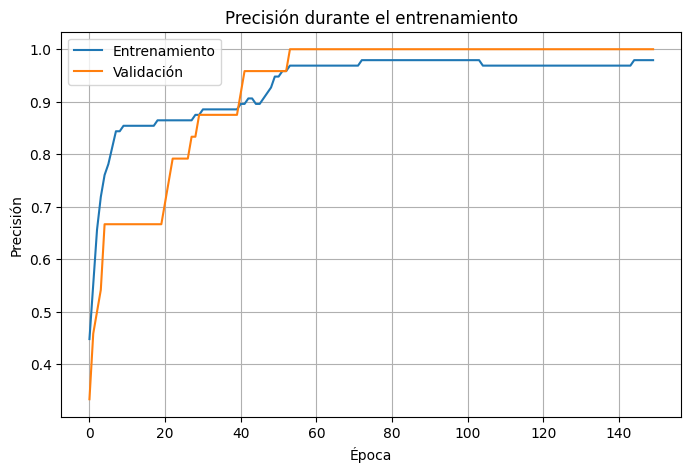

In [ ]:
history = model.fit(
    X_train_s, y_train,
    validation_split=0.20,
    epochs=150,
    batch_size=16,
    verbose=0
)

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Precisión durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluación
prob = model.predict(X_test_s, verbose=0)
pred = np.argmax(prob, axis=1)

acc = accuracy_score(y_test, pred)
print(f"Precisión en prueba: {acc:.3f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, pred, target_names=clases))

print("Matriz de confusión:")
print(confusion_matrix(y_test, pred))

Precisión en prueba: 0.967

Reporte de clasificación:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## Ejemplos de internet

Los siguientes ejemplos corresponden a medidas publicadas para flores Iris. Se introducen únicamente las cuatro features que necesita el modelo.

El objetivo es comprobar si el modelo puede clasificar observaciones que no se le presentan con el formato completo del dataset.

In [ ]:
# Ejemplos externos: [sepal length, sepal width, petal length, petal width]
# Los valores se pueden modificar por otros ejemplos tomados de una fuente pública.
ejemplos_internet = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.7, 3.1, 5.6, 2.4]
], columns=features)

prob_ext = model.predict(
    scaler.transform(ejemplos_internet), verbose=0
)

pred_ext = np.argmax(prob_ext, axis=1)

resultados_ext = ejemplos_internet.copy()
resultados_ext["Predicción"] = [clases[i] for i in pred_ext]
resultados_ext["Confianza"] = np.max(prob_ext, axis=1)

display(resultados_ext)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predicción,Confianza
0,5.1,3.5,1.4,0.2,Iris-setosa,0.998768
1,6.0,2.9,4.5,1.5,Iris-versicolor,0.910129
2,6.7,3.1,5.6,2.4,Iris-virginica,0.999713


## Análisis

Para cada ejemplo se compara la especie esperada según la fuente externa con la predicción de la red. Además de la clase, se observa la probabilidad máxima entregada por la capa softmax como una medida de confianza del modelo.

Una clasificación correcta de un ejemplo externo no demuestra por sí sola que el modelo generalice perfectamente; es necesario evaluar varios ejemplos y mantener separados los datos usados para entrenamiento y prueba.

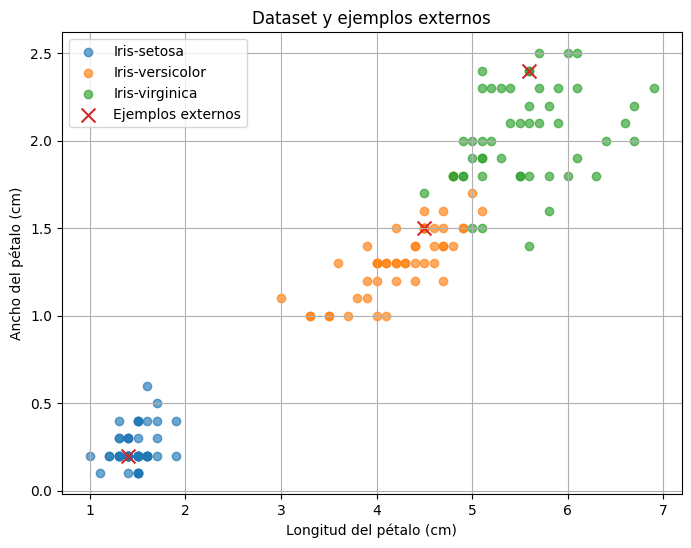

In [ ]:
# Análisis visual de los ejemplos externos
plt.figure(figsize=(8,6))
for clase in clases:
    mask = y_text == clase
    plt.scatter(
        X[mask, 2], X[mask, 3],
        label=clase, alpha=0.65
    )

plt.scatter(
    ejemplos_internet["PetalLengthCm"],
    ejemplos_internet["PetalWidthCm"],
    marker="x", s=100, label="Ejemplos externos"
)

plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.title("Dataset y ejemplos externos")
plt.legend()
plt.grid(True)
plt.show()

## Conclusión

El dataset presenta cuatro variables de entrada cuantitativas y tres categorías de salida. La red neuronal aprende una relación no lineal entre las medidas de las flores y su especie. La prueba con ejemplos externos permite analizar la capacidad de generalización del modelo fuera de las observaciones utilizadas directamente durante el entrenamiento.

**Fuente del dataset:** Kaggle, *Iris Species*, UCI Machine Learning.